<a href="https://colab.research.google.com/github/Rogerio-mack/AD_solucao/blob/main/Aula_07_Regressao_solucao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão

## Exemplo de Regressão: Grilos e Temperatura

**Lei de Dolbear**. Dolbear estabeleceu em 1897 uma fórmula matemática direta baseada em regressão linear para determinar a temperatura com base na frequencia  de gorjeios para a espécie Oecanthus fultoni (AE Dolbear (1897) · https://www.journals.uchicago.edu/doi/pdf/10.1086/276739)

Grilos gorjeiam com mais frequência em dias quentes que em dias freios e profissionais e amadores coletaram dados sobre o gorjeio desses insetos por minuto e as temperaturas chegando a modelo linear que permite, através do número de gorjeios por minuto (a variável ou atributo preditor) estimar a temperatura (o rótulo, ou a variável objetivo). Os dados a seguir simulam esses dados.

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


In [69]:
from IPython.display import IFrame

IFrame('https://www.nationalgeographic.pt/ciencia/canto-grilos-temperatura-ambiente_4098', width=800, height=450)

In [70]:
#@markdown Just run
np.random.seed(1)
df = pd.DataFrame()

df['temperature'] = np.arange(0,45,1)
df['chirps'] = (20 * df['temperature'] - 4) / 16
df['chirps'] = df['chirps'] + np.round(np.random.sample(len(df))*5,0)

df.to_csv('chirps.csv',index=False)


,temperature,chirps
0,0,1.75
1,1,5.00
2,2,2.25
3,3,5.50
4,4,5.75


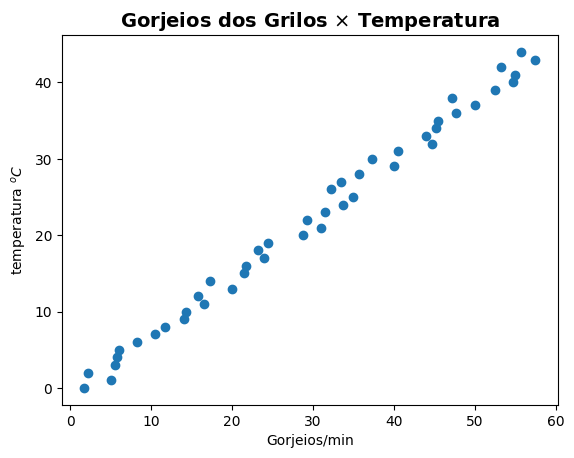

In [71]:
df = pd.read_csv('chirps.csv')
display(df.head())

plt.scatter(df['chirps'],df['temperature'])

plt.title('Gorjeios dos Grilos $\\times$ Temperatura', fontsize=14, weight='bold')
plt.xlabel('Gorjeios/min')
plt.ylabel('temperatura $^{o}C$')
plt.show()

Como você pode ver os dados se aproximam bastante de uma 'reta', um modelo linear, e podemos esperar escrever algo como:

$$ \text{Temperatura} = a_0 + a_1 \times \text{Gorjeios/min} $$

Que é a equação de uma reta.

Modelos de regressão podem ser ainda polinomiais, exponenciais etc., (diferentes classes de modelos de regressão), mas  escolhemos um modelo linear para aproximar os dados por quê observando os dados *esperamos* poder aproximá-los por uma reta! Os modelos lineares é a classe de modelos de regressão que escolhemos para aproximar nossos dados.

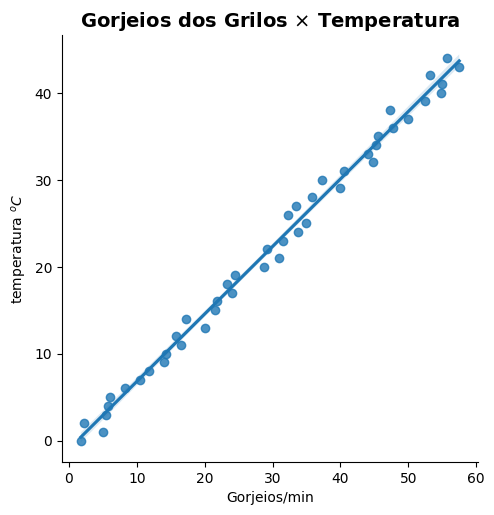

In [72]:
sns.lmplot(x='chirps',y='temperature', data=df)

plt.title('Gorjeios dos Grilos $\\times$ Temperatura', fontsize=14, weight='bold')
plt.xlabel('Gorjeios/min')
plt.ylabel('temperatura $^{o}C$')
plt.show()

Um modelo de regressão linear busca encontrar a reta que melhor se ajusta a esse conjunto de dados calculando os melhores coeficientes $a_0$ e $a_1$ que tornam os valores $\text{Temperatura}$ mais próximos dos valores reais.

## Obtendo os coeficientes com o `statsmodels`

In [73]:
import statsmodels.formula.api as sm

# Definição do modelo
lm = sm.ols(formula='temperature ~ chirps', data=df)

# Treinamento
lm = lm.fit()

# Resultados
print(lm.summary())



                            OLS Regression Results                            
Dep. Variable:            temperature   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                     5334.
Date:                Mon, 21 Sep 2026   Prob (F-statistic):           9.94e-47
Time:                        15:31:33   Log-Likelihood:                -70.585
No. Observations:                  45   AIC:                             145.2
Df Residuals:                      43   BIC:                             148.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9595      0.361     -2.659      0.0

Por hora, note apenas que os resultados do modelo acima mostram os coeficientes obtidos, `Intercept` e `chirps`. O  `Intercept` é o coeficiente livre da equação da reta que não está associado a qualquer variável preditora e recebe este nome por ser o valor que 'intercepta' o eixo $y$ quando os valores de todas as variáveis preditoras é nulo. `chirps` é o coeficiente dos gorjeios.

$$ \text{Temperatura} = -0.9595 + 0.7761 \times \text{Gorjeios/min} $$


E podemos empregar essa expressão para estimar a temperatura no caso de observarmos 32 gorjeios por minuto,



In [74]:
Gorjeios_Observados = 32
Temperatura_Estimada = -0.9595 + 0.7761 * Gorjeios_Observados
print(f'{Temperatura_Estimada:.2f} oC')

23.88 oC


Ou, o que é mais comum e em geral mais simples, empregar a função `predict` que aplica o modelo,

In [75]:
Gorjeios_Observados = pd.DataFrame({'chirps': [32]})
Temperatura_Estimada = lm.predict(Gorjeios_Observados)[0]

print(f'{Temperatura_Estimada:.2f} oC')

23.88 oC


# Regressão Linear

Entendido como funcionam os modelos em geral podemos agora nos concentrar unicamente em como criar e avaliar modelos de Regressão Linear.

Um modelo linear aproxima o valor de variável objetivo $Y$ a partir de uma combinação linear das variáveis preditoras $X$.

$$ \widehat y = a_0 + a_{1} x_1 + a_{2} x_2 + ... + a_{n} x_n $$

A cada variável preditora corresponde um coeficiente $a_n$, havendo um coeficiente independente que corresponte ao valor de $\widehat y$ para $X=0$ (*intercept*). Se temos uma única variável preditora $x_1$ nosso modelo é uma reta e temos um modelo de **Regressão Simples**. Se temos mais dimensões temos um *hiperplano* e o modelo é uma **Regressão Múltipla**.  

Existem também outros modelos de Regressão. Por exemplo, um modelo de Regressão Polinomial busca aproximar os dados a um polinômio de grau $n$ e $ \widehat y = a_0 + a_{1} x_1^1 + a_{2} x_1^2 + ... + a_{n} x_1^n $ seria um modelo de Regressão Polinomial Simples de grau 2. Esses são modelos de **regressão não linear**, mas nos deteremos aqui unicamente em modelos lineares.






## Calculando os Coeficientes de uma Regressão Simples

No caso mais simples, nosso problema consiste em dados um conjunto de pontos $(x,y)$,  determinar os coeficientes da reta que melhor aproxima $r: x\rightarrow y$.

In [76]:
# you can skip this code!
from scipy.stats import norm

x = np.arange(0, 100)
y = 2*x + 3
y = y + norm.rvs(loc=0, scale=50, size=100, random_state=1234)

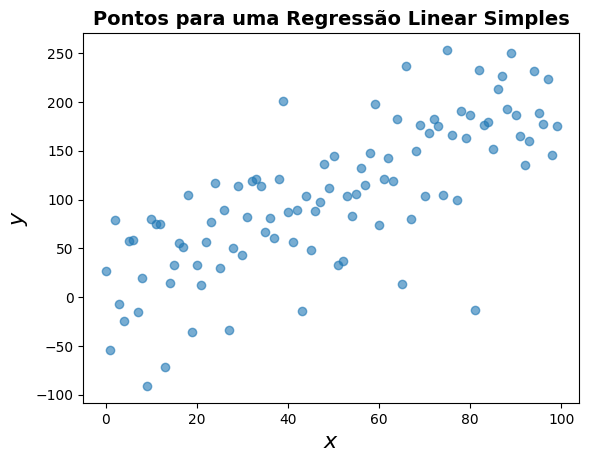

In [77]:
plt.scatter(x,y,alpha=0.6)
plt.title('Pontos para uma Regressão Linear Simples', fontsize=14, weight='bold')
plt.xlabel('$x$', fontsize=16)
plt.ylabel('$y$', fontsize=16)
plt.show()

Dado um conjunto de pontos podemos traçar várias retas que *aproximam* de diferentes modos o conjunto de pontos. A regressão linear simples é definida pela reta que minimiza o erro ou a distância dos pontos $y$ dos valores estimados $\hat{y}$.

Dado um conjunto de pontos $(x_i,y_i), i=0,...,n$ queremos buscar a reta $\hat{y} = a + b x$ que reduz o erro das estimativas de $y$. Esse erro pode ser medido pela distância dos pontos $y$ e $\hat{y}$, ou mais simplesmente pela distância quadrática, e podemos escrever esse erro em função de $a$ e $b$, que ainda não conhecemos os valores:

$$ E(a,b) = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 $$
$$ E(a,b) = \sum_{i=1}^{n}(y_i - a - b x_i)^2 $$

O ponto de mínimo da função de Erro $E(a,b)$ fornece os valores $a$ e $b$ dos coeficientes da reta,

$$ \min_{a, b} E(a,b) = \min_{a, b} \sum_{i=1}^{n}(y_i - a - b x_i)^2 $$

e pode ser obtido a partir das derivadas com relação a esses parâmetros,

$$ \partial E / \partial a =  -2 \sum_{i=1}^{n}(y_i - a - b x_i) = 0$$

$$ \partial E / \partial b =  -2 \sum_{i=1}^{n}x_i(y_i - a - b x_i) = 0 $$

Resolvendo-se esse sistema de equações você obtêm:

$$ a = \bar{y} - b \bar{x} $$
onde $\bar{y}$ e $\bar{x}$ são a média dos valores $y_i$ e $x_i$, e:

$$ b = \frac{ \sum_{i=1}^{n} (x_i - \bar{x}) (y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2 } $$

Os valores dessa expressão não devem ser estranhos a você. De fato,  eles são a $cov(x,y)$ e a $var(x)$ e, desse modo, podemos escrever simplesmente:


$$ b = \frac{cov(x,y)}{var(x)}  $$

<br>

$$ a = \bar{y} - b \bar{x} $$

Empregando o conjunto de pontos acima podemos verificar os coeficientes produzidos:


In [78]:
# A diagonal da matriz contém a covariância entre cada variável e ela mesma

b = np.cov(x,y)[1,0] / np.var(x); print(b)
a = np.mean(y) - b*np.mean(x); print(a)

1.9850551363966769
5.495384904636339


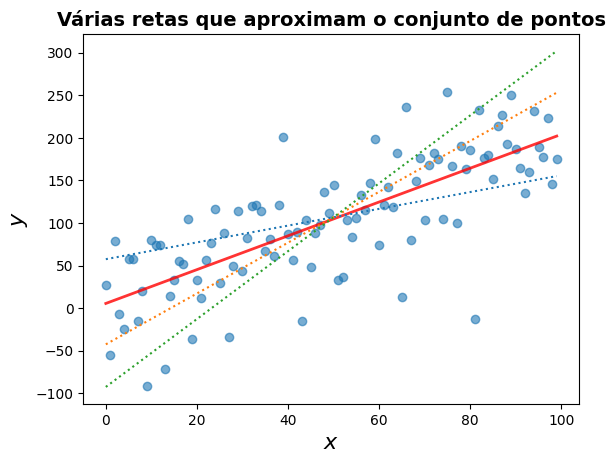

In [79]:
# you can skip this code!

y2 = a + b*x
y3 = (y2[51] - 50*(b-1))+(b-1)*x
y4 = (y2[51] - 50*(b+1))+(b+1)*x
y5 = (y2[51] - 50*(b+2))+(b+2)*x

plt.scatter(x, y, alpha=0.6)
plt.plot(x, y2, c='red', lw=2, alpha=0.8)
plt.plot(x, y3, linestyle='dotted')
plt.plot(x, y4, linestyle='dotted')
plt.plot(x, y5, linestyle='dotted')

plt.title('Várias retas que aproximam o conjunto de pontos', fontsize=14, weight='bold')
plt.xlabel('$x$', fontsize=16)
plt.ylabel('$y$', fontsize=16)
plt.show()

E, assim, determinamos a reta que melhor estima os valores de $y$:

$$ \hat{y} = a + bx = 1.98 + 5.49 x $$

<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_2890/3132820640.py:9: SyntaxWarning: invalid escape sequence '\h'
  plt.text(55,-60,'$ \hat{y} = 1.98 + 5.49 x $', fontsize=16)


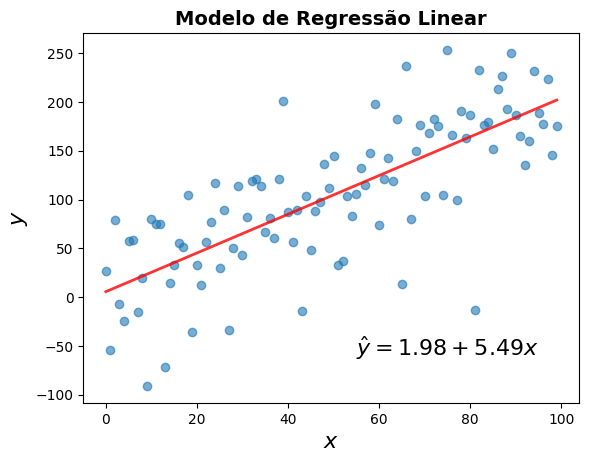

In [80]:
# you can skip this code!

plt.scatter(x, y, alpha=0.6)
plt.plot(x, y2, c='red', lw=2, alpha=0.8)

plt.title('Modelo de Regressão Linear', fontsize=14, weight='bold')
plt.xlabel('$x$', fontsize=16)
plt.ylabel('$y$', fontsize=16)
plt.text(55,-60,'$ \hat{y} = 1.98 + 5.49 x $', fontsize=16)
plt.show()

# Regressão Linear Múltipla

No modelo linear mais geral o valor de variável objetivo, ou dependente, $y$ é obtido a partir de uma combinação linear de um conjunto de variáveis preditoras, ou dependentes, $X$.

$$  \widehat y = a_0 + a_{1} x_{1} + a_{2} x_{2} + ... + a_{n} x_{n} $$

Agora, a cada variável preditora corresponde um coeficiente $a_n$, havendo um coeficiente independente que corresponte ao valor de $\widehat y$ para $X_i=0$ (*intercept*).

Os coeficientes $a_n$ são obtidos do mesmo modo que na regressão simples, minimizando-se o erro  entre os valores de $y$  nos dados e os valores estimados $\widehat y$, e podemos escrever:

$$ \min_{a_i}\sum (y_i - \widehat y_i )^2 = $$

$$ \min_{a_i} \sum (y_i - (a_0 + a_{1} x_{1} + ... + a_{n} x_{n}) )^2 $$

Não há, entretanto, nenhuma fórmula ou expressão para obtermos de forma algébrica os valores de $a_i$ que são obitidos, de modo geral, aplicando-se algum método de otimização, como o  método de mínimos quadrados, sendo o erro uma função convexa que garante a existência de um único ponto de mínimo.

> **Para quaisquer conjuntos de dados $(X, y)$ sempre é possível se calcular os coeficientes de uma regressão linear. Esses coeficientes fornecem sempre a melhor reta ou *hiperplano* que se ajusta os dados. A pergunta é: seria esse ajuste é suficientemente bom?**








# Avaliando a Eficiência do Modelo: Coeficiente de Determinação, $R^2$

No caso de uma regressão simples podemos calcular diretamente os coeficientes $a$ e $b$ empregando apenas os valores médios de $x$ e $y$, a $cov(x,y)$ e a $var(x)$. Assim, para quaisquer conjuntos de dados podemos *sempre* calcular um modelo de regressão *mesmo que o modelo linear não represente exatamente nossos dados*.  Isso é ilustrado pelo exemplo a seguir.


In [81]:
# you can skip this code!

x = np.arange(-10,10,1)
ruido = norm.rvs(loc=0, scale=1, size=len(x), random_state=1234)
df = pd.DataFrame({'dataset':'I','x':x,'y': 2*x + 3 + ruido})
df = pd.concat( [df, pd.DataFrame({'dataset':'II','x':x,'y': 2*x**2 + 3 }) ])
df = pd.concat( [df, pd.DataFrame({'dataset':'III','x':x,'y': x**3 - 2*x }) ])
df = pd.concat( [df, pd.DataFrame({'dataset':'IV','x':x,'y': np.exp(1)**x }) ])

In [82]:
df

,dataset,x,y
0,I,-10,-16.528565
1,I,-9,-16.190976
2,I,-8,-11.567293
3,I,-7,-11.312652
4,I,-6,-9.720589
...,...,...,...
15,IV,5,148.413159
16,IV,6,403.428793
17,IV,7,1096.633158
18,IV,8,2980.957987


Modelo de Regressão, Dataset: I  
1.991 x + 2.984
Modelo de Regressão, Dataset: II  
-2 x + 69
Modelo de Regressão, Dataset: III  
58.4 x - 19.8
Modelo de Regressão, Dataset: IV  
171.9 x + 726.9


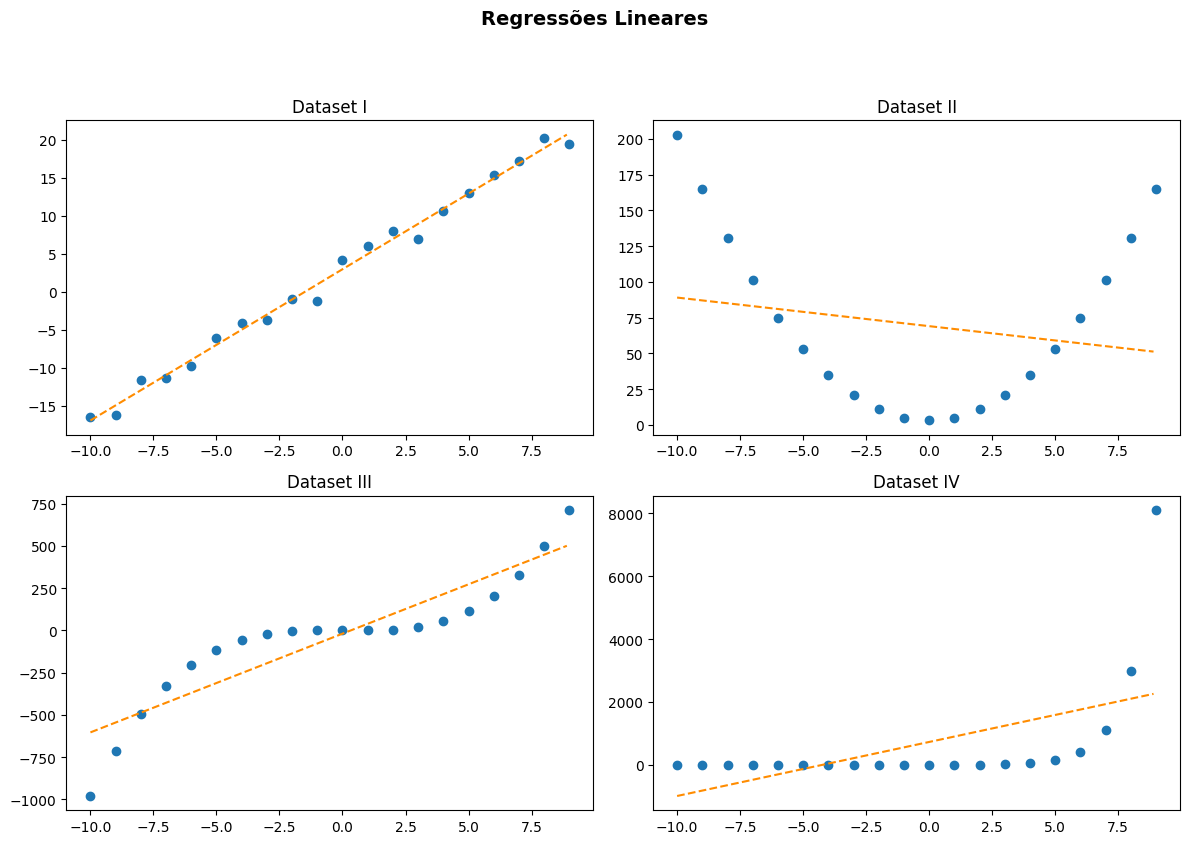

In [83]:
# you can skip this code!

fig, ax = plt.subplots(2,2,figsize=(12,8))

fig.suptitle('Regressões Lineares', fontsize=14, weight='bold', y=1.05)

i = 0
for ds_type in df.dataset.unique():
  ds = df[df.dataset == ds_type]

  z = np.polyfit(ds.x, ds.y, 1)
  p = np.poly1d(z)
  print('Modelo de Regressão, Dataset:', ds_type, p)

  ax[i//2,i%2].scatter(ds.x,ds.y)

  x = np.arange(ds.x.min(), ds.x.max(), 0.1)
  ax[i//2,i%2].plot(x,p(x),color='darkorange', linestyle='dashed')

  ax[i//2,i%2].set_title('Dataset ' + ds_type)

  i += 1

plt.tight_layout()
plt.show()

Os quatro conjuntos de dados acima foram obtidos aplicando-se as funções:

$ (I) \space \space  \space \space y = 2x + 3 + \epsilon , \text{onde} \space  \epsilon = \text{noise} $

$ (II) \space \space  \space \space y = 2x^2 + 3   $

$ (III) \space \space  \space \space y  =  x^3 - 2x  $

$ (IV) \space \space  \space \space y  = x cos(x) + x   $

Embora apenas o conjunto de dados $I$ se ajuste de fato a um modelo linear você pode notar que podemos calcular o modelo linear em todos os casos, *mesmo ele não se ajustando aos dados*!

No caso de uma regressão simples você pode observar o ajuste ou não do modelo fazendo uma inspeção visual como acima. Mas o mesmo pode ocorrer no caso de uma regressão múltipla e, neste caso, havendo mais dimensões você não poderá observar o ajuste dos dados ao modelo. Por isso é necessário termos uma métrica, uma medida que avalia a **eficiência do modelo**, ou o quanto os dados se ajustam ao nosso modelo proposto. A métrica mais importante para uma regressão linear é o **Coeficiente de Determinação**, $R^2$ ou ainda $R-Square$.

O **Coeficiente de Determinação** é uma medida no intervalo $[0,1]$ que indica o quanto um modelo linear explica a variância de um conjunto de dados. Quanto mais próximo de $1$ o valor do $R^2$, mais os dados se ajustam ao  modelo linear.

$$ R^2 = 1 - \frac{E_{res}}{E_{total}} $$


onde

$$E_{res} = \sum (y_i - \widehat y_i )^2 $$  é a *soma dos quadrados residuais* e,

$$E_{total} = \sum (y_i - \bar y )^2 $$


é a *soma total dos quadrados*.




De fato, como você pode observar, somente o primeiro conjunto dos quatro conjuntos de dados acima têm apresentam um coeficiente de determinação próximo de 1.

In [84]:
# you can skip this code!

R2 = {}
for ds_type in df.dataset.unique():
  ds = df[df.dataset == ds_type]

  z = np.polyfit(ds.x, ds.y, 1)
  p = np.poly1d(z)

  R2[ds_type] = 1 - sum((ds.y - p(ds.x))**2) / sum((ds.y - np.mean(y))**2)

for dataset, r2 in R2.items():
  print('Dataset ' + dataset + ', R-Square = ' + str(np.round(r2,4)))


Dataset I, R-Square = 0.9999
Dataset II, R-Square = 0.266
Dataset III, R-Square = 0.8505
Dataset IV, R-Square = 0.3459


Basicamente o coeficiente de determinação é uma medida de proporção que verifica o quanto variância dos dados está representada no modelo com relação ao modelo trivial $y = \bar{x}$.


<br>
<br>
<br>
<img src="https://upload.wikimedia.org/wikipedia/commons/8/86/Coefficient_of_Determination.svg"  width=500, align="center">
<br>
<br>
<br>

<small>
<b>
Figura 4. À esquerda, em vermelho, as variâncias com relação ao modelo trivial e, à direita, as variâncias do modelo de regressão (em azul). <br></b>(Fonte: Wikipedia)

O $R^2$ é útil para avaliarmos a adequação de um modelo de regressão linear aos dados e pode também ser empregado para compararmos modelos que disputam entre si. Por exemplo, você pode ter dois modelos de regressão múltipla para obter o preço de imóveis. Um deles considera um atributo adicional *bairro  do imóvel*, o outro não. O coeficiente então pode ser empregado para avaliar qual o melhor modelo.

> **Você vai encontrar essas métricas de avaliação de eficiência dos modelos para quaisquer modelos supervisionados e elas podem ser empregadas na busca de um melhor modelo, ajustando parâmetros de um modelo ou na seleção entre vários modelos que competem.**

# $R^2$ Ajustado

O $R^2$ Ajustado é uma medida alternativa para avaliação do modelo e existem ainda outras métricas.

A inclusão de inúmeras variáveis, mesmo com pouco poder explicativo sobre a variável dependente, podem sempre aumentar o valor de $R^2$. Isso é um incentivo para a inclusão indiscriminada de variáveis, prejudicando o princípio da parcimônia (princípio da *navalha de Ockham*) em que o aumento de complexidade não leva a ganhos proporcionais no modelo. Para evitar isso você pode empregar o coeficiente de determinação ajustado que penaliza a inclusão de preditores pouco explicativos no modelo:  

$${\displaystyle {\bar {R^{2}}}=1-{\frac {n-1}{n-(k+1)}}\left(1-R^{2}\right),}
 $$

$k+1 $ representa o número de variáveis explicativas mais a constante, e a inclusão de variáveis pouco explicativas passa a penalizar o valor do $R^2$ com o valor ajustado para baixo.

## Analisando a Eficiência do Modelo

O Sumário acima ainda traz o Coeficiente de Determinação e os *p-values* dos coeficientes. O primeiro você já conhece e é uma medida geral da eficiência do modelo.

$$ R^2 = 0.979 $$

Esse é um valor bastante próximo de 1 e que garante termos um modelo que explica bastante bem os dados.

Outra medida importante de se observar são os $p-values$ dos coeficientes. Eles são um teste de hipótese sobre os valores dos coeficientes onde a hipótese nula é de que os coeficientes são não significativos ($= 0$). A hipótese alternativa é de que o coeficiente é significativo (e, portanto $\ne 0$). Assim, $ p-values < 0.05 $ indicarão que o coeficiente é significativo para o modelo e podemos observar que para os dois coeficientes acima (`Intercept` e `x`) os valores são significativos.

$$ p-value(a_i) < 0.05 \Rightarrow a_i \space \text{é Significativo} $$

Podemos assim, dizer que

$$ \hat y = -4.9986 + 2.0272 x $$

é um modelo que aproxima bastante bem os dados.

Existem várias outras métricas nos resultados acima, mas para os nossos propósitos a análise acima já é suficiente.

> **$R^2$ qual é um bom valor? Novamente não existe um modelo 'certo' e a questão é melhor formulada em termos de: qual é um bom resultado para os seus propósitos? Mas de modo geral valores $R^2 > 0.8$ já são bastante úteis mesmo para predições e com valores abaixo $R^2 < 0.6$ recomendaríamos buscar outros modelos de aproximação dos dados.**


# Erros Comuns na Interpretação do Modelo

Dois erros são bastante comuns na intepretação de modelos de regressão linear e nos dois casos, podem levar a conclusões bastante errôneas.





## $R^2 \approx  0 \Rightarrow $ não há relação entre os dados.

Isso não é necessariamente verdade.

## $R^2 \approx 1 \Rightarrow $ então $x$ é **causa** e $y$ **efeito**.

Isso não é necessariamente verdade.

Talvez ainda mais comum que o erro anterior e até mais grave é concluírmos a partir de uma regressão linear válida uma relação de **causa-efeito** entre essas variáveis, embora em muitos casos isso possa ser verdade.

A área de um imóvel e sua idade tem, em geral, um efeito sobre o preço do imóvel, e a renda de um país tem um efeito sobre a expectativa de vida das pessoas, o que pode ser observado se implementamos um modelo, linear ou não. Mas a presença de relação linear entre os dados **não garante** que exista uma relação de causa-efeito. Uma relação linear apenas diz que observando os valores das variáveis independentes podemos estimar com alguma confiança os valores da variável dependente. Isso não permite determinar quem é a causa ou quem é o efeito e nem mesmo se existe uma relação de causa-efeito. Ambas, por exemplo, podem ter uma causa comum e, portanto, seus valores podem simplesmente *andarem* juntos e há uma série de casos de correlações espúrias entre os dados.






<img src="https://github.com/Rogerio-mack/Machine-Learning-I/raw/main/Figures/spurious1.png" width=800, align="center">


<img src="https://github.com/Rogerio-mack/Machine-Learning-I/raw/main/Figures/spurious2.png" width=800, align="center">

<small>

<b>
Figura 4. Relações espúrias entre dados exibindo uma correlação bastante alta ~ 0.99. Uma interpretação errada poderia levar a entendermos que os gastos com ciência são a causa de um maior número de suicídios (acima) ou que um menor consumo de margarina pode levar a uma redução do número de divórcios (abaixo). Uma nota: não nos deteremos aqui nas diferenças de correlação e coeficiente de determinação, pois não altera o observado aqui e não tem relevância para os nossos propósitos. Fonte: https://www.tylervigen.com/spurious-correlations

# Exercício

1. Faça um modelo inicial de **Regressão Linear Simples** para previsão de preços dos veículos empregando somente a potência do motor dos veículos (`horsepower`). O resultado foi bom? Qual o $R2$ do modelo? Qual a predição para veículos com potência de 150 e 180 hp?

2. Faça um modelo de **Regressão Múltipla** para previsão de preços dos veículos empregando **todas** as variáveis preditoras numéricas, mas excluindo as multicolinearidades `'MinPrice','MaxPrice','MPGhighway'`. Em seguida, refine o modelo empregando somente as variáveis com coeficientes significativos ($p < 0.05$). Qual o $R2$ do modelo? Qual a predição para veículos com valores correspondentes à média dos veículos?

3. Faça agora um modelo de **Regressão Múltipla** adicionando ao modelo anterior o atributo categórico `Manufacturer` (e o `intercept` caso tenha sido excluído antes). Qual o $R2$ do novo modelo? Veja o que ocorre com a variável `Manufacturer` no modelo.

In [85]:
df = pd.read_csv("https://vincentarelbundock.github.io/Rdatasets/csv/MASS/Cars93.csv",index_col=0)
df.columns = [ x.replace('.','') for x in df.columns ] # statsmodels não suporta "." no nome dos atributos
df.head()

,Manufacturer,Model,Type,MinPrice,Price,MaxPrice,MPGcity,MPGhighway,AirBags,DriveTrain,...,Passengers,Length,Wheelbase,Width,Turncircle,Rearseatroom,Luggageroom,Weight,Origin,Make
rownames,,,,,,,,,,,,,,,,,,,,,
1,Acura,Integra,Small,12.9,15.9,18.8,25,31,NaN,Front,...,5,177,102,68,37,26.5,11.0,2705,non-USA,Acura Integra
2,Acura,Legend,Midsize,29.2,33.9,38.7,18,25,Driver & Passenger,Front,...,5,195,115,71,38,30.0,15.0,3560,non-USA,Acura Legend
3,Audi,90,Compact,25.9,29.1,32.3,20,26,Driver only,Front,...,5,180,102,67,37,28.0,14.0,3375,non-USA,Audi 90
4,Audi,100,Midsize,30.8,37.7,44.6,19,26,Driver & Passenger,Front,...,6,193,106,70,37,31.0,17.0,3405,non-USA,Audi 100
5,BMW,535i,Midsize,23.7,30.0,36.2,22,30,Driver only,Rear,...,4,186,109,69,39,27.0,13.0,3640,non-USA,BMW 535i


## Exercício 1: Regressão Linear Simples

In [86]:
import statsmodels.formula.api as sm

model = sm.ols(formula="Price ~ Horsepower", data=df)


In [87]:
result = model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.617
Method:                 Least Squares   F-statistic:                     149.3
Date:                Mon, 21 Sep 2026   Prob (F-statistic):           6.84e-21
Time:                        15:31:34   Log-Likelihood:                -297.23
No. Observations:                  93   AIC:                             598.5
Df Residuals:                      91   BIC:                             603.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.3988      1.820     -0.769      0.4

Obtemos assim o modelo:

$$ \hat{Price} =  -1.3988 + 0.1454 \times \text{Horsepower} $$   




In [90]:
df['predicted'] = result.predict()

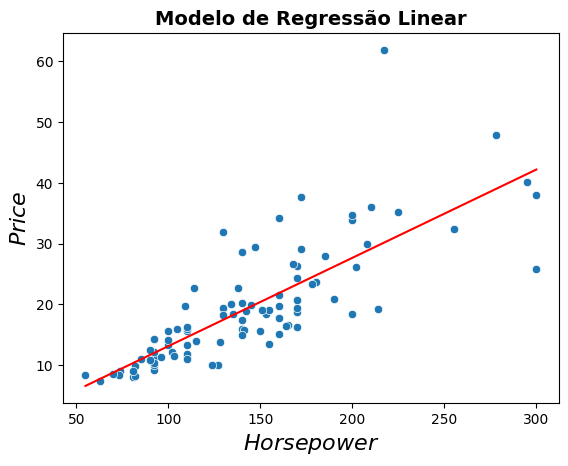

In [91]:
sns.scatterplot(x='Horsepower', y='Price', data=df)
sns.lineplot(x='Horsepower', y='predicted', data=df, color='red')

plt.title('Modelo de Regressão Linear', fontsize=14, weight='bold')
plt.xlabel('$Horsepower$', fontsize=16)
plt.ylabel('$Price$', fontsize=16)

plt.show()


In [92]:
x = pd.DataFrame({'Horsepower': [150,180]})
result.predict(x)

,0
0,20.406915
1,24.768052




$$ R^2 = 0.621$$
$$ p-values = 0.444 > 0.05 \text{, para o intercept}$$

O intercept poderia ser excluído.



## Exercício 2: Regressão Linear Múltipla



In [93]:
df.select_dtypes(include=['int64','float64']).columns

Index(['MinPrice', 'Price', 'MaxPrice', 'MPGcity', 'MPGhighway', 'EngineSize',
       'Horsepower', 'RPM', 'Revpermile', 'Fueltankcapacity', 'Passengers',
       'Length', 'Wheelbase', 'Width', 'Turncircle', 'Rearseatroom',
       'Luggageroom', 'Weight', 'predicted'],
      dtype='object')

In [94]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
target = 'Price'
formula = f'{target} ~ {" + ".join(df[numeric_cols].drop(columns=[target]+['MinPrice','MaxPrice','MPGhighway']))}'
formula

'Price ~ MPGcity + EngineSize + Horsepower + RPM + Revpermile + Fueltankcapacity + Passengers + Length + Wheelbase + Width + Turncircle + Rearseatroom + Luggageroom + Weight + predicted'

In [95]:
import statsmodels.formula.api as sm

model = sm.ols(formula=formula, data=df)
result = model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.738
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                     13.51
Date:                Mon, 21 Sep 2026   Prob (F-statistic):           1.88e-14
Time:                        15:32:26   Log-Likelihood:                -249.34
No. Observations:                  82   AIC:                             528.7
Df Residuals:                      67   BIC:                             564.8
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           13.0765     10.829  

/tmp/ipykernel_2890/3386805681.py:4: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  result = model.fit()


### Refinando o modelo

In [96]:
model = sm.ols(formula="Price ~ Width	+ Horsepower - 1", data=df)
result = model.fit()
print(result.summary())

                                 OLS Regression Results                                
Dep. Variable:                  Price   R-squared (uncentered):                   0.926
Model:                            OLS   Adj. R-squared (uncentered):              0.925
Method:                 Least Squares   F-statistic:                              571.6
Date:                Mon, 21 Sep 2026   Prob (F-statistic):                    3.01e-52
Time:                        15:32:30   Log-Likelihood:                         -297.11
No. Observations:                  93   AIC:                                      598.2
Df Residuals:                      91   BIC:                                      603.3
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [66]:
x = pd.DataFrame({'Width': [ df.Width.mean() ],
                  'Horsepower': [ df.Horsepower.mean() ]})
preco_estimado = result.predict(x)[0]

print(f'Preço estimado (US$ 1000): {preco_estimado:.2f}')

Preço estimado (US$ 1000): 19.48


## Exercício 3: Adicionando Variáveis Categóricas

O pacote `statsmodel` permite empregar variáveis categóricas diretamente. Como o cálculo dos coeficientes requer atributos numéricos o pacote transforma esses atributos internamente fazendo o *hot encode* dos dados.



In [100]:
df.select_dtypes(include=['object']).columns

Index(['Manufacturer', 'Model', 'Type', 'AirBags', 'DriveTrain', 'Cylinders',
       'Mantransavail', 'Origin', 'Make'],
      dtype='object')

In [105]:
model = sm.ols(formula="Price ~ Manufacturer + Width + Horsepower", data=df)
result = model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.902
Model:                            OLS   Adj. R-squared:                  0.847
Method:                 Least Squares   F-statistic:                     16.47
Date:                Mon, 21 Sep 2026   Prob (F-statistic):           1.75e-19
Time:                        15:35:58   Log-Likelihood:                -234.34
No. Observations:                  93   AIC:                             536.7
Df Residuals:                      59   BIC:                             622.8
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     